<a href="https://colab.research.google.com/github/nunotfc-png/Caeser-Cipher/blob/master/EX02_Previsao_abandono.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EX02 — Previsão de Abandono (Churn)
**UC: Análise de Dados de Negócio** · Aula 1

---

Previsão de churn com Logistic Regression, Decision Tree e Random Forest. Curvas ROC, importância de variáveis e threshold de decisão com custo de negócio.

**Dataset:** Telco Customer Churn (IBM/Kaggle)  
**URL:** https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

**Outputs gerados:** `clientes_churn_scores.csv` · `roc_comparison.png` · `feature_importance_churn.png`


In [1]:
# @title ⚙️ Instalação de Dependências (executar uma vez por sessão)

# Todas as bibliotecas necessárias já estão pré-instaladas no Google Colab.
# pandas, numpy, scikit-learn, matplotlib, seaborn estão disponíveis por omissão.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GREEN, RED = '#0891B2', '#0D9488', '#EF4444'

In [ ]:
# Caso não seja configurado o Google Drive
# Os ficheiros ficam em /content/ (sessão temporária):
OUTPUT_DIR = '/content/'
print(f"Directório de output: {OUTPUT_DIR}")

## PARTE 1 — CARREGAMENTO

In [2]:
# Dataset: Telco Customer Churn (Kaggle / IBM Sample)
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Carregar via URL directa (IBM sample dataset)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
# Análise Exploratória Simples
print("Shape:", df.shape)
print("\n", df.info())
print("\n", df.isnull().sum())
print("\n", df['Churn'].value_counts(normalize=True).mul(100).round(1))

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

## PARTE 2 — PRÉ-PROCESSAMENTO

In [4]:
# Cópia da tabela
df2 = df.copy()

# TotalCharges pode ter espaços (problema conhecido no dataset)
df2['TotalCharges'] = pd.to_numeric(df2['TotalCharges'], errors='coerce')
df2['TotalCharges'].fillna(df2['TotalCharges'].median(), inplace=True)

# Remover customerID (identificador)
df2.drop(columns=['customerID'], inplace=True, errors='ignore')

# Variável target
df2['Churn'] = df2['Churn'].map({'Yes': 1, 'No': 0})

# Codificação de variáveis categóricas (one-hot)
df2 = pd.get_dummies(df2, drop_first=True)
df2.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [6]:
# Divide datasets features + classe (churn)
X = df2.drop(columns='Churn')
y = df2['Churn']

# Split treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Normalizar
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## PARTE 3 — TREINO DE MODELOS E AVALIAÇÃO

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='roc_auc').mean()
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'AUC': auc, 'CV_AUC': cv}
    print(f"\n{'='*40}")
    print(f"Modelo: {name}")
    print(f"AUC Teste: {auc:.3f} | AUC Cross-val (5-fold): {cv:.3f}")
    print(classification_report(y_test, y_pred, target_names=['Não Churn', 'Churn']))


Modelo: Logistic Regression
AUC Teste: 0.846 | AUC Cross-val (5-fold): 0.844
              precision    recall  f1-score   support

   Não Churn       0.85      0.90      0.87      1294
       Churn       0.66      0.56      0.60       467

    accuracy                           0.81      1761
   macro avg       0.76      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761


Modelo: Decision Tree
AUC Teste: 0.823 | AUC Cross-val (5-fold): 0.827
              precision    recall  f1-score   support

   Não Churn       0.83      0.91      0.87      1294
       Churn       0.65      0.47      0.54       467

    accuracy                           0.79      1761
   macro avg       0.74      0.69      0.70      1761
weighted avg       0.78      0.79      0.78      1761


Modelo: Random Forest
AUC Teste: 0.826 | AUC Cross-val (5-fold): 0.823
              precision    recall  f1-score   support

   Não Churn       0.83      0.90      0.86      1294
       Churn   

## PARTE 4 — CURVAS ROC E COMPARAÇÃO

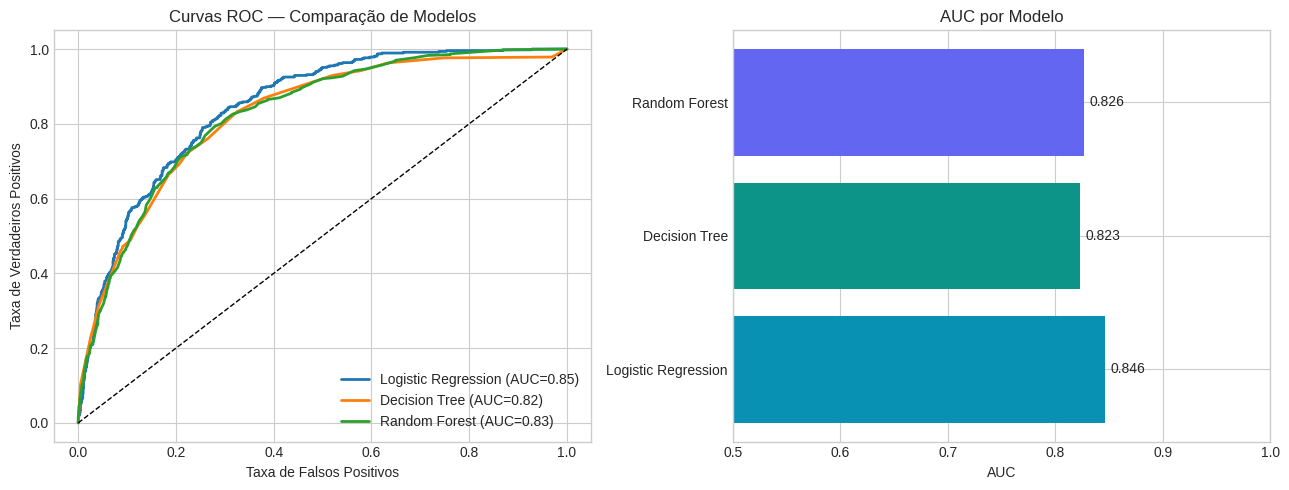

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curvas ROC
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['AUC']:.2f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curvas ROC — Comparação de Modelos')
axes[0].legend()

# Barras AUC
names = list(results.keys())
aucs  = [r['AUC'] for r in results.values()]
bars  = axes[1].barh(names, aucs, color=[BLUE, GREEN, '#6366F1'])
axes[1].set_xlim(0.5, 1.0)
axes[1].set_xlabel('AUC')
axes[1].set_title('AUC por Modelo')
for bar, v in zip(bars, aucs):
    axes[1].text(v + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('/content/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 5 — IMPORTÂNCIA DE VARIÁVEIS (RANDOM FOREST)

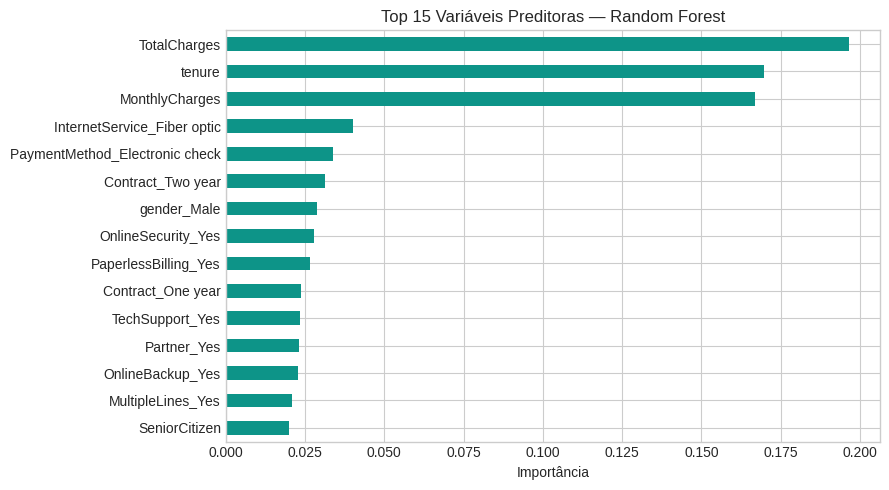

In [10]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
top15.sort_values().plot.barh(ax=ax, color=GREEN)
ax.set_title('Top 15 Variáveis Preditoras — Random Forest')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig('/content/feature_importance_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 6 — MATRIZ DE CONFUSÃO DO MELHOR MODELO

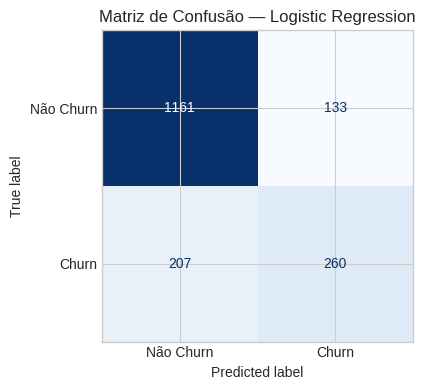

In [13]:
best_name = max(results, key=lambda k: results[k]['AUC'])
best_pred = results[best_name]['y_pred']

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred,
    display_labels=['Não Churn', 'Churn'],
    colorbar=False, ax=ax,
    cmap='Blues'
)
ax.set_title(f'Matriz de Confusão — {best_name}')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 7 — EXPORTAR PROBABILIDADES PARA POWER BI

In [15]:
# Usamos o melhor modelo para gerar probabilidades de churn para todos os clientes
best_model = results[best_name]['model']
X_all_sc = scaler.transform(X)
df['ChurnProb'] = best_model.predict_proba(X_all_sc)[:, 1]
df['ChurnPred'] = (df['ChurnProb'] >= 0.5).astype(int)
df['ChurnScore'] = pd.cut(df['ChurnProb'],
                           bins=[0, 0.3, 0.6, 1.0],
                           labels=['Baixo', 'Médio', 'Alto'])

df.to_csv('/content/clientes_churn_scores.csv', index=False)
print(f"\nFicheiro 'clientes_churn_scores.csv' guardado.")
print(f"Melhor modelo: {best_name} | AUC: {results[best_name]['AUC']:.3f}")


Ficheiro 'clientes_churn_scores.csv' guardado.
Melhor modelo: Logistic Regression | AUC: 0.846


# Perguntas de reflexão
1. Qual o custo de um Falso Negativo e de um Falso Positivo?
Como isso afecta o threshold de decisão?
2. O dataset tem desequilíbrio de classes (~26% churn).
Experimenta SMOTE (from imblearn.over_sampling import SMOTE) e compara os resultados.
3. Qual variável tem mais impacto no churn? É consistente com a intuição de negócio?
4. Que tipo de contrato está mais associado ao churn? Calcula a taxa de churn por Contract e visualiza.